In [14]:
import numpy as np
from qiskit import QuantumCircuit,transpile
from qiskit_ibm_runtime import Sampler,QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Operator

In [15]:
service = QiskitRuntimeService(channel="ibm_quantum")

In [16]:
def phase_oracle(n, indices_to_mark, name='Oracle'):
    qc = QuantumCircuit(n, name=name)
    oracle_matrix = np.identity(2**n)
    for index_to_mark in indices_to_mark:
        oracle_matrix[index_to_mark, index_to_mark] = -1
    qc.unitary(Operator(oracle_matrix), range(n))
    return qc

def diffuser(n):
    qc = QuantumCircuit(n, name='Diff - "V"')
    qc.h(range(n))
    qc.append(phase_oracle(n, [0]), range(n))
    qc.h(range(n))
    return qc

def Grover(n, marked):
    qc = QuantumCircuit(n, n)
    r = int(np.round(np.pi/(4*np.arcsin(np.sqrt(len(marked)/2**n)))-1/2))
    print(f'{n} qubits, basis state {marked}, {r} rounds')
    qc.h(range(n))
    for _ in range(r):
        qc.append(phase_oracle(n, marked), range(n))
        qc.append(diffuser(n), range(n))
    qc.measure(range(n),range(n))   
    return qc

In [19]:
n = 5
x = np.random.randint(2**n)
marked = [x]
qc = Grover(n , marked)
qc.draw()

5 qubits, basis state [31], 4 rounds


┌───┐┌─────────┐┌─────────────┐┌─────────┐┌─────────────┐┌─────────┐»
q_0: ┤ H ├┤0        ├┤0            ├┤0        ├┤0            ├┤0        ├»
     ├───┤│         ││             ││         ││             ││         │»
q_1: ┤ H ├┤1        ├┤1            ├┤1        ├┤1            ├┤1        ├»
     ├───┤│         ││             ││         ││             ││         │»
q_2: ┤ H ├┤2 Oracle ├┤2 Diff - "V" ├┤2 Oracle ├┤2 Diff - "V" ├┤2 Oracle ├»
     ├───┤│         ││             ││         ││             ││         │»
q_3: ┤ H ├┤3        ├┤3            ├┤3        ├┤3            ├┤3        ├»
     ├───┤│         ││             ││         ││             ││         │»
q_4: ┤ H ├┤4        ├┤4            ├┤4        ├┤4            ├┤4        ├»
     └───┘└─────────┘└─────────────┘└─────────┘└─────────────┘└─────────┘»
c: 5/════════════════════════════════════════════════════════════════════»
                                                                         »
«     ┌─────────────┐┌─────────┐┌─────────────┐┌─┐            
«q_0: ┤0            ├┤0        ├┤0            ├┤M├────────────
«     │             ││         ││             │└╥┘┌─┐         
«q_1: ┤1            ├┤1        ├┤1            ├─╫─┤M├─────────
«     │             ││         ││             │ ║ └╥┘┌─┐      
«q_2: ┤2 Diff - "V" ├┤2 Oracle ├┤2 Diff - "V" ├─╫──╫─┤M├──────
«     │             ││         ││             │ ║  ║ └╥┘┌─┐   
«q_3: ┤3            ├┤3        ├┤3            ├─╫──╫──╫─┤M├───
«     │             ││         ││             │ ║  ║  ║ └╥┘┌─┐
«q_4: ┤4            ├┤4        ├┤4            ├─╫──╫──╫──╫─┤M├
«     └─────────────┘└─────────┘└─────────────┘ ║  ║  ║  ║ └╥┘
«c: 5/══════════════════════════════════════════╩══╩══╩══╩══╩═
«                                               0  1  2  3  4

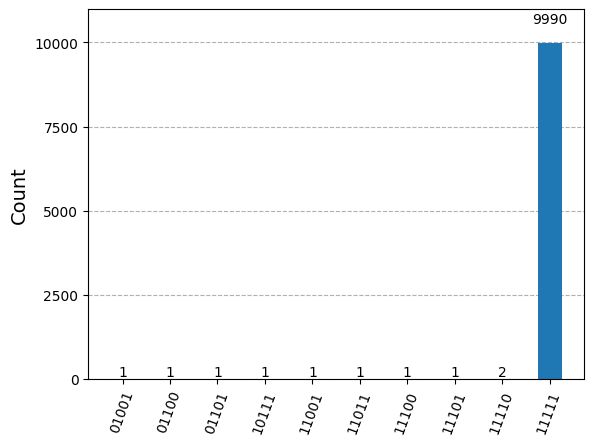

In [20]:
from qiskit_aer import AerSimulator
backend = AerSimulator()
transpiled_circuit = transpile(qc,backend=backend)
job = backend.run(transpiled_circuit,shots=10000)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

In [21]:
print(counts)

{'11111': 9990, '01001': 1, '11100': 1, '10111': 1, '01100': 1, '11011': 1, '01101': 1, '11110': 2, '11101': 1, '11001': 1}


In [23]:
backend = service.least_busy(
    filters= lambda b:(
        b.configuration().n_qubits > n
        and not b.configuration().simulator
        and b.status().operational
    )
)
print("Least bbusy backend name: ",backend.name)
transpiled_circuit = transpile(qc,backend,optimization_level=3)

Least bbusy backend name:  ibm_kyiv


In [24]:
from qiskit_ibm_runtime import Sampler
sampler = Sampler(mode=backend)
shots  =1024
job = sampler.run([transpiled_circuit],shots=shots)
result = job.result()

SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=5>)), metadata={'circuit_metadata': {}})


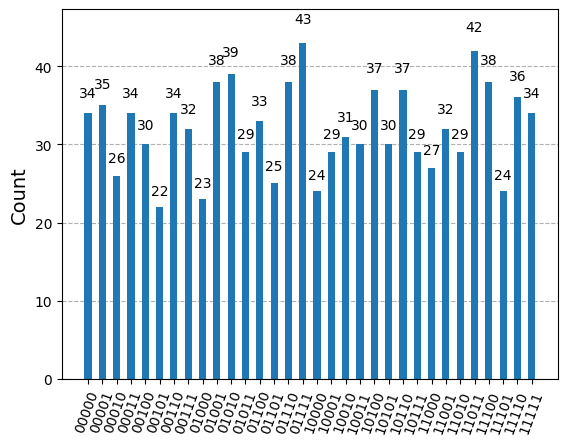

In [25]:
# Access the first (and only) result
first_result = result[0]
print(first_result)
# DataBin to a counts dictionary
counts = result[0].data.c.get_counts()
plot_histogram(counts)

In [26]:
n = 3
marked = [5]
qc = Grover(n , marked)
qc.draw()

3 qubits, basis state [5], 2 rounds


┌───┐┌─────────┐┌─────────────┐┌─────────┐┌─────────────┐┌─┐      
q_0: ┤ H ├┤0        ├┤0            ├┤0        ├┤0            ├┤M├──────
     ├───┤│         ││             ││         ││             │└╥┘┌─┐   
q_1: ┤ H ├┤1 Oracle ├┤1 Diff - "V" ├┤1 Oracle ├┤1 Diff - "V" ├─╫─┤M├───
     ├───┤│         ││             ││         ││             │ ║ └╥┘┌─┐
q_2: ┤ H ├┤2        ├┤2            ├┤2        ├┤2            ├─╫──╫─┤M├
     └───┘└─────────┘└─────────────┘└─────────┘└─────────────┘ ║  ║ └╥┘
c: 3/══════════════════════════════════════════════════════════╩══╩══╩═
                                                               0  1  2

Least bbusy backend name:  ibm_kyiv
SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=3>)), metadata={'circuit_metadata': {}})


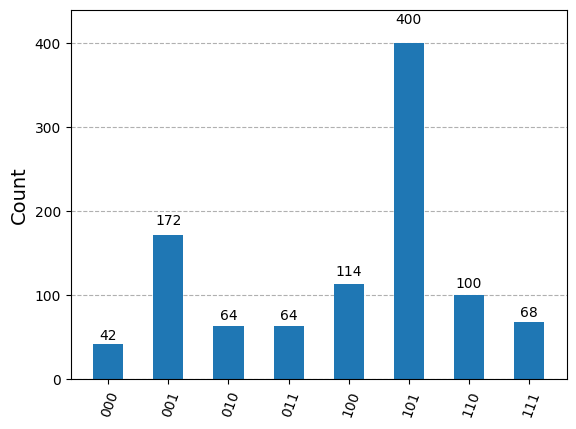

In [27]:
backend = service.least_busy(
    filters= lambda b:(
        b.configuration().n_qubits > n
        and not b.configuration().simulator
        and b.status().operational
    )
)
print("Least bbusy backend name: ",backend.name)
transpiled_circuit = transpile(qc,backend,optimization_level=3)
sampler = Sampler(mode=backend)
shots  =1024
job = sampler.run([transpiled_circuit],shots=shots)
result = job.result()
# Access the first (and only) result
first_result = result[0]
print(first_result)
# DataBin to a counts dictionary
counts = result[0].data.c.get_counts()
plot_histogram(counts)